# Proyecto Parcial 1
- Lopez Montero Ivana Abigail
- Jaramillo Rodriguez Leslie Citlalli
- Salas Hernandez Camila Alexandra



# FFT iterativa con inversión de bits (N = 256)

**Radix-2, decimación en el tiempo (DIT), in-place.**

Algoritmo:

1. **Reordenar** la entrada por inversión de bits (`x[n]` pasa a la posición `bit_reverse(n)`).
2. Aplicar **log₂N = 8 etapas** de mariposas. En la etapa `s` (con `m = 2^s`):
   - Se procesan bloques de tamaño `m`.
   - Factor de giro: $W_m^k = e^{-j2\pi k/m}$, con $k = 0,\dots,m/2-1$.
   - Mariposa:
     $$u = X[i+k],\quad v = W_m^k\,X[i+k+m/2]$$
     $$X[i+k]=u+v,\qquad X[i+k+m/2]=u-v$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

## 1. Inversión de bits

In [2]:
def bit_reverse(n, bits):
    """Invierte los 'bits' bits menos significativos de n."""
    r = 0
    for _ in range(bits):
        r = (r << 1) | (n & 1)
        n >>= 1
    return r

# Ejemplo con N = 8 (3 bits)
print(" n  binario  invertido  nuevo índice")
for n in range(8):
    r = bit_reverse(n, 3)
    print(f" {n}   {n:03b}      {r:03b}        {r}")

 n  binario  invertido  nuevo índice
 0   000      000        0
 1   001      100        4
 2   010      010        2
 3   011      110        6
 4   100      001        1
 5   101      101        5
 6   110      011        3
 7   111      111        7


## 2. FFT iterativa

In [3]:
def fft_iterativa(x):
    """FFT radix-2 DIT iterativa con reordenamiento por inversión de bits."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    bits = int(np.log2(N))
    if 2**bits != N:
        raise ValueError("N debe ser potencia de 2")

    # 1) Reordenamiento por inversión de bits
    X = np.zeros(N, dtype=complex)
    for n in range(N):
        X[bit_reverse(n, bits)] = x[n]

    # 2) Etapas de mariposas
    for s in range(1, bits + 1):
        m = 2**s                          # tamaño del bloque
        Wm = np.exp(-2j * np.pi / m)      # giro base de la etapa
        for i in range(0, N, m):          # cada bloque
            W = 1.0 + 0j
            for k in range(m // 2):       # cada mariposa del bloque
                u = X[i + k]
                v = W * X[i + k + m // 2]
                X[i + k] = u + v
                X[i + k + m // 2] = u - v
                W *= Wm
    return X

## 3. Señal de prueba y verificación

In [4]:
N = 256
fs = 1000
n = np.arange(N)
t = n / fs
x = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)

X = fft_iterativa(x)
X_np = np.fft.fft(x)

print("Error máximo vs numpy.fft:", np.max(np.abs(X - X_np)))
print("¿Coinciden?", np.allclose(X, X_np))

Error máximo vs numpy.fft: 2.7149799812125933e-13
¿Coinciden? True


## 4. Gráficas

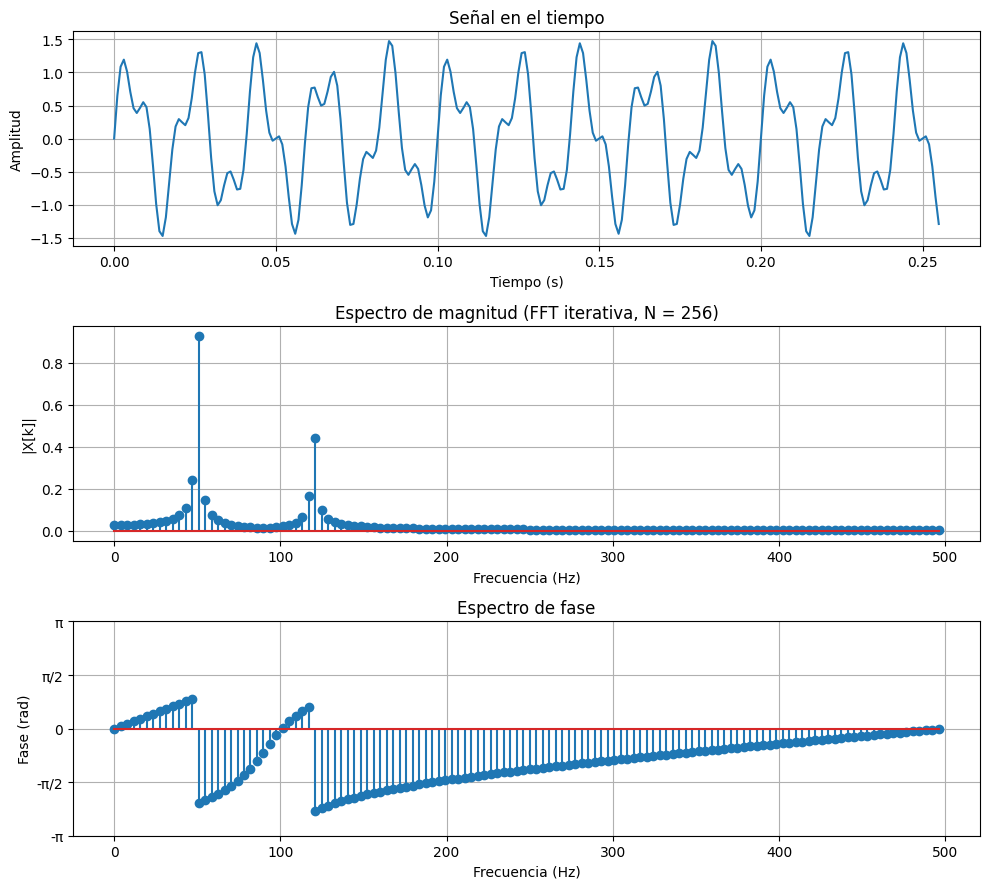

f = 50.8 Hz  |  magnitud = 0.928  |  fase = -2.182 rad
f = 121.1 Hz  |  magnitud = 0.444  |  fase = -2.424 rad


In [5]:
f = np.arange(N) * fs / N
mag = np.abs(X)

# La fase solo tiene sentido donde hay energía; en los demás bins es ruido numérico
fase = np.angle(X)
fase[mag < 1e-6 * mag.max()] = 0

fig, ax = plt.subplots(3, 1, figsize=(10, 9))

ax[0].plot(t, x)
ax[0].set_title("Señal en el tiempo")
ax[0].set_xlabel("Tiempo (s)"); ax[0].set_ylabel("Amplitud"); ax[0].grid(True)

ax[1].stem(f[:N//2], mag[:N//2] * 2 / N)
ax[1].set_title("Espectro de magnitud (FFT iterativa, N = 256)")
ax[1].set_xlabel("Frecuencia (Hz)"); ax[1].set_ylabel("|X[k]|"); ax[1].grid(True)

ax[2].stem(f[:N//2], fase[:N//2])
ax[2].set_title("Espectro de fase")
ax[2].set_xlabel("Frecuencia (Hz)"); ax[2].set_ylabel("Fase (rad)")
ax[2].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax[2].set_yticklabels(["-π", "-π/2", "0", "π/2", "π"])
ax[2].grid(True)

plt.tight_layout()
plt.show()

# Fase en los picos
for k in np.argsort(mag[:N//2])[-2:][::-1]:
    print(f"f = {f[k]:.1f} Hz  |  magnitud = {mag[k]*2/N:.3f}  |  fase = {fase[k]:.3f} rad")